# Streaming Diarization Results Analysis

This notebook analyzes the evaluation results from streaming diarization experiments on the CallHome German dataset.

**Experiment:** `callhome_deu`  
**Systems Compared:**
- `diart_default` - DIART with default parameters
- `diart_custom` - DIART with custom parameters
- `streaming_sortformer` - Streaming SortFormer system

## Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%load_ext autoreload
%autoreload 2

# Import analysis modules
import data_loader
import visualizations
import stats_report

import importlib
importlib.reload(visualizations)

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Evaluation Results

In [6]:
# Load the metrics CSV file
csv_path = Path("../results/callhome_deu/metrics.csv")
df = data_loader.load_metrics(csv_path, verbose=True)

✓ Loaded 360 results from ..\results\callhome_deu\metrics.csv
  Number of recordings: 120
  Systems evaluated: diart_default, diart_custom, streaming_sortformer
  Metrics captured: 26 columns
  Created derived metrics (RTF)


## Data Overview

In [7]:
# Display sample of data
display(df.head())

# Print dataset summary
stats_report.print_dataset_summary(df)

,recording_id,system,DER,false_alarm,missed_detection,confusion,JER,latency_mean_ms,latency_std_ms,peak_latency_ms,peak_latency_chunk_idx,num_chunks,step_size_ms,duration,peak_gpu_mem_mb,peak_gpu_util_pct,avg_gpu_util_pct,peak_ram_mb,avg_cpu_percent,wall_time_s,total_speech_time,gt_num_speakers,gt_overlap_rate,avg_segment_confidence,min_segment_confidence,rtf
0,callhome_deu_0000,diart_default,0.2943,15.948,121.529,37.971,0.3285,67.5206,28.6630,372.7548,0,1195,500.0,601.88,1020.5128,43,34.7465,4096.9216,389.7228,84.9627,596.082,2,0.0923,NaN,NaN,0.1412
1,callhome_deu_0001,diart_default,0.2299,32.089,66.304,21.331,0.4869,67.4312,27.6225,180.5696,1149,1196,500.0,602.35,636.3740,44,32.7746,4148.6582,395.8671,83.6853,520.754,3,0.0504,NaN,NaN,0.1389
2,callhome_deu_0002,diart_default,0.2252,13.178,96.896,48.227,0.3265,67.3351,27.5645,165.4530,838,1195,500.0,601.89,636.3740,38,33.9437,4184.6047,394.6938,83.8843,702.818,2,0.1815,NaN,NaN,0.1394
3,callhome_deu_0003,diart_default,0.5264,29.270,79.858,197.761,0.6652,66.4995,27.6393,124.0737,1180,1193,500.0,600.89,636.3740,43,34.0986,4205.0560,396.9151,82.6420,583.024,2,0.0900,NaN,NaN,0.1375
4,callhome_deu_0004,diart_default,0.2409,14.771,20.914,38.305,0.3674,66.7810,27.6777,166.9687,351,594,500.0,301.36,636.3740,44,34.0704,4097.6507,396.6049,41.0038,307.078,2,0.0944,NaN,NaN,0.1361



DATASET SUMMARY
Total recordings: 120
Systems evaluated: diart_default, diart_custom, streaming_sortformer
Total rows: 360
Columns: 26


## Ground Truth Dataset Characteristics

Analysis of the CallHome German dataset properties used for evaluation.

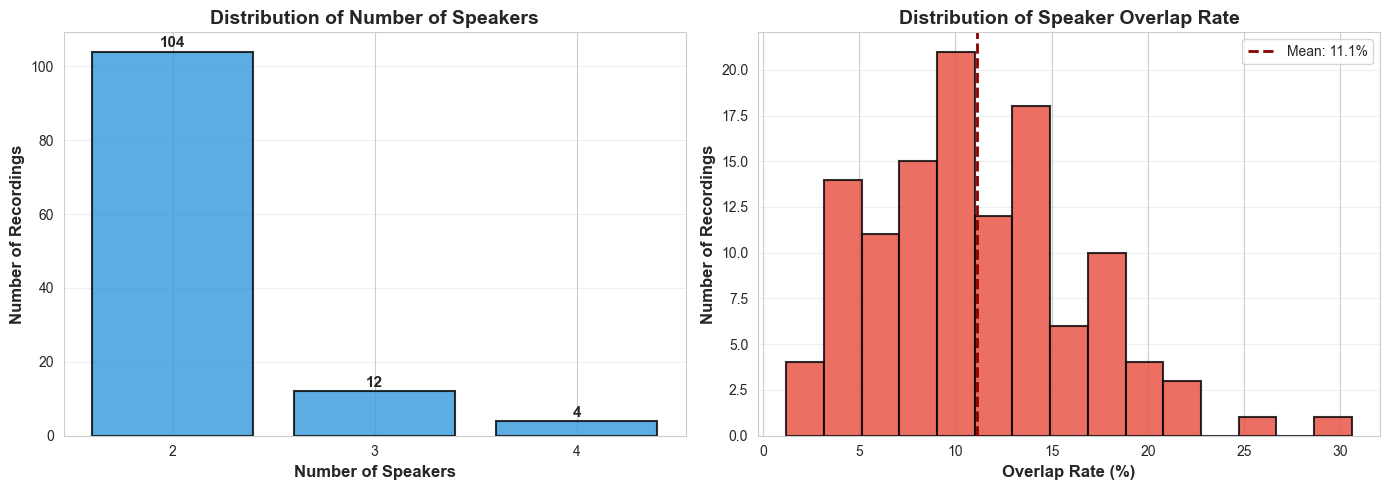

In [8]:
# Prepare ground truth data
gt_data = data_loader.prepare_ground_truth_data(df)

# Plot ground truth characteristics
visualizations.plot_ground_truth_characteristics(gt_data)

## DER Component Analysis

Breakdown of Diarization Error Rate (DER) into its components: False Alarm, Missed Detection, and Speaker Confusion.

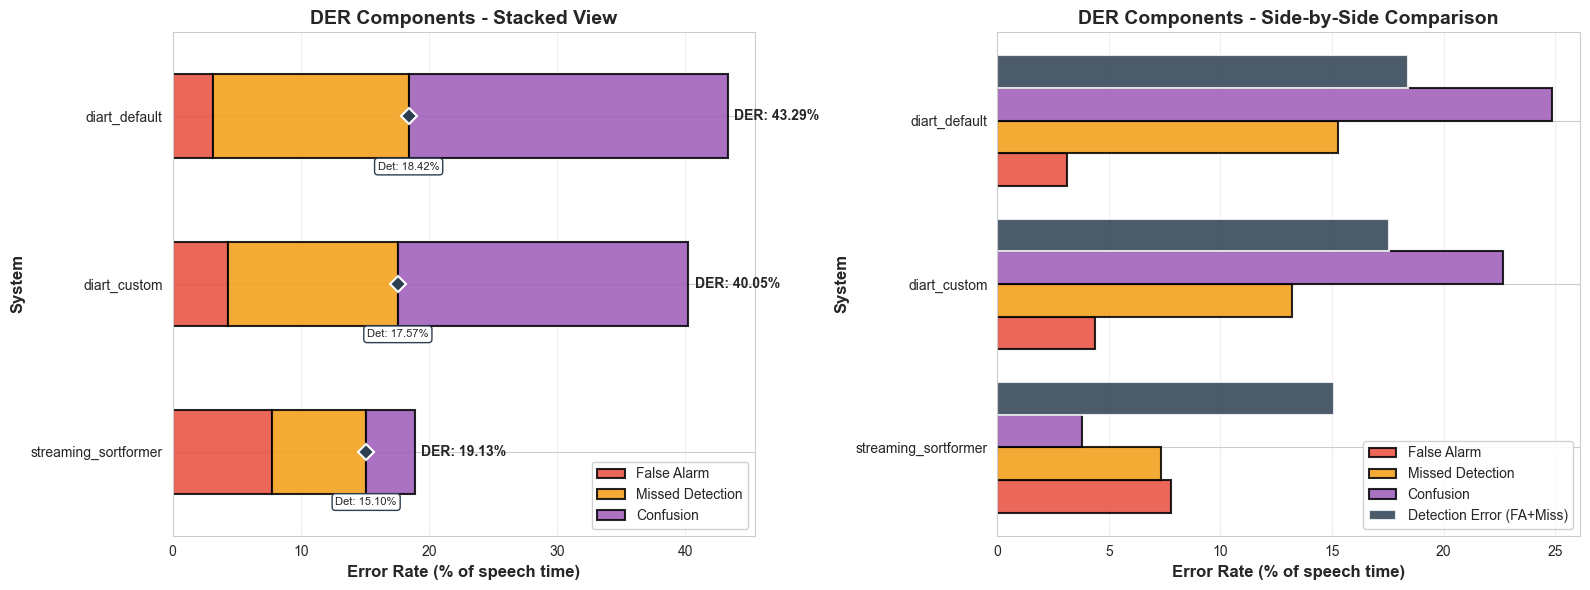


DER COMPONENT ANALYSIS

streaming_sortformer:
  Total DER:          19.13%
  ├─ False Alarm:      7.77% ( 40.6% of DER)
  ├─ Missed Detect:    7.33% ( 38.3% of DER)
  └─ Confusion:        3.78% ( 19.8% of DER)

diart_custom:
  Total DER:          40.05%
  ├─ False Alarm:      4.37% ( 10.9% of DER)
  ├─ Missed Detect:   13.21% ( 33.0% of DER)
  └─ Confusion:       22.64% ( 56.5% of DER)

diart_default:
  Total DER:          43.29%
  ├─ False Alarm:      3.14% (  7.3% of DER)
  ├─ Missed Detect:   15.27% ( 35.3% of DER)
  └─ Confusion:       24.87% ( 57.4% of DER)


In [9]:
# Plot DER components analysis
visualizations.plot_der_components(df)

# Print detailed component analysis
stats_report.print_der_component_analysis(df)

## DER per Recording Analysis

Heatmap showing DER for each recording across all systems.

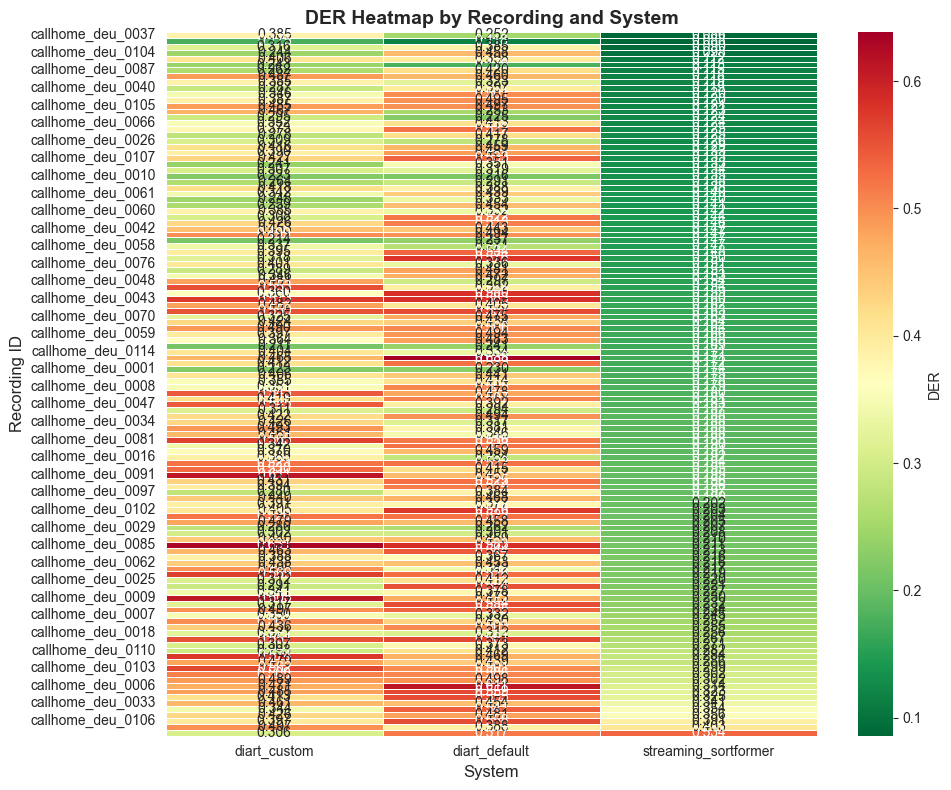


BEST PERFORMING SYSTEM PER RECORDING
streaming_sortformer    117
diart_custom              2
diart_default             1
Name: count, dtype: int64


In [10]:
# Plot DER heatmap sorted by streaming_sortformer performance
der_pivot = visualizations.plot_der_heatmap(df, sort_by_system='streaming_sortformer')

# Show which system wins for each recording
stats_report.print_best_system_per_recording(der_pivot)

## DER vs. Overlap Rate

Analysis of how speaker overlap affects diarization accuracy.

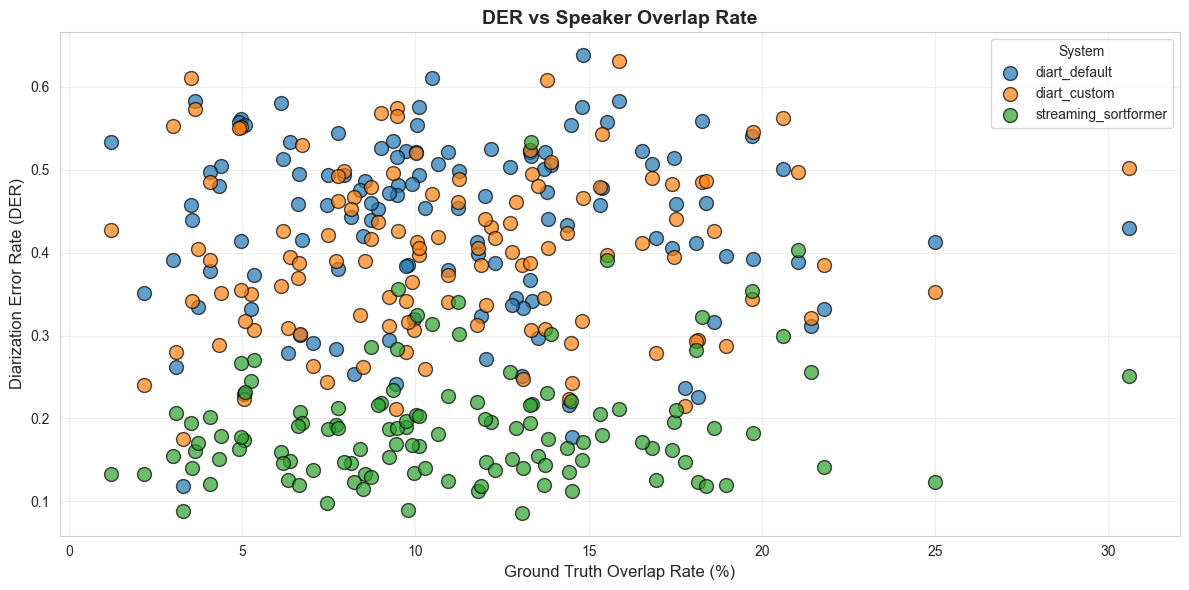


Correlation: DER vs overlap rate
------------------------------------------------------------
diart_default            : -0.010
diart_custom             : +0.089
streaming_sortformer     : +0.200


In [11]:
# Plot DER vs overlap rate scatter
visualizations.plot_der_vs_overlap(df)

# Print correlation analysis
stats_report.print_correlation_analysis(df, metric='DER', variable='gt_overlap_rate', 
                           variable_display_name='overlap rate')

## Processing Efficiency

Real-Time Factor (RTF) and processing time analysis.

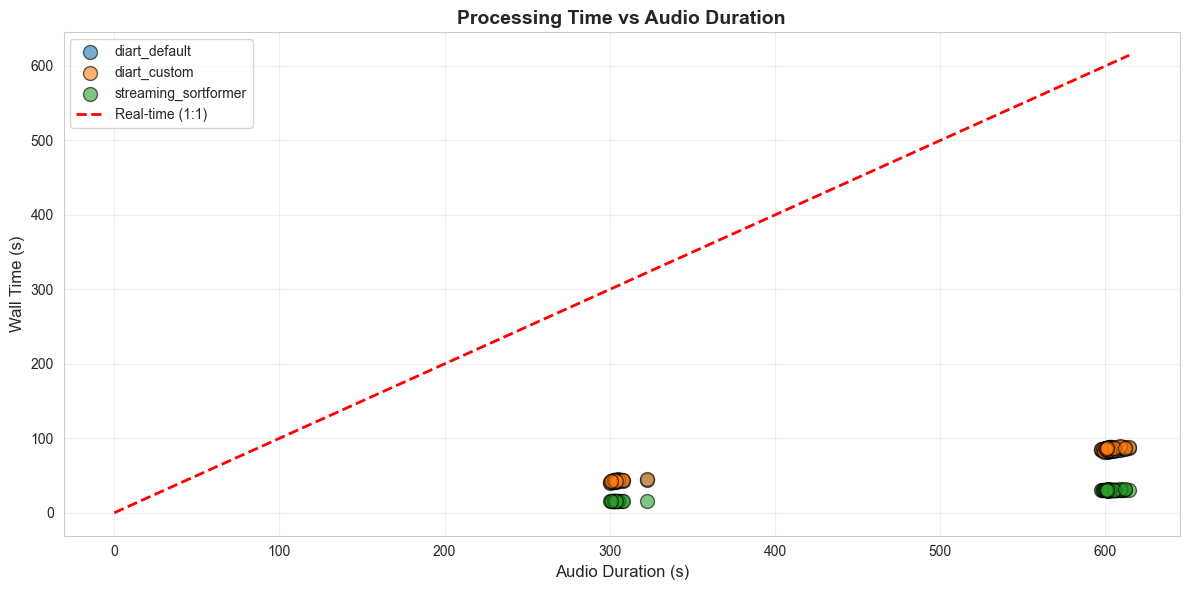

In [17]:
# Print RTF statistics
# stats_report.print_rtf_statistics(df)

# Plot processing efficiency
visualizations.plot_processing_efficiency(df)

## Resource Usage

GPU, RAM, and CPU utilization statistics.


RESOURCE USAGE STATISTICS
                      peak_gpu_mem_mb  avg_gpu_util_pct  peak_ram_mb  \
system                                                                 
diart_custom                 636.3740           36.5222    4314.0605   
diart_default                639.5752           33.6258    4055.1928   
streaming_sortformer         606.0240           93.3244    4526.6656   

                      avg_cpu_percent  
system                                 
diart_custom                 397.4058  
diart_default                396.8897  
streaming_sortformer          99.8417  


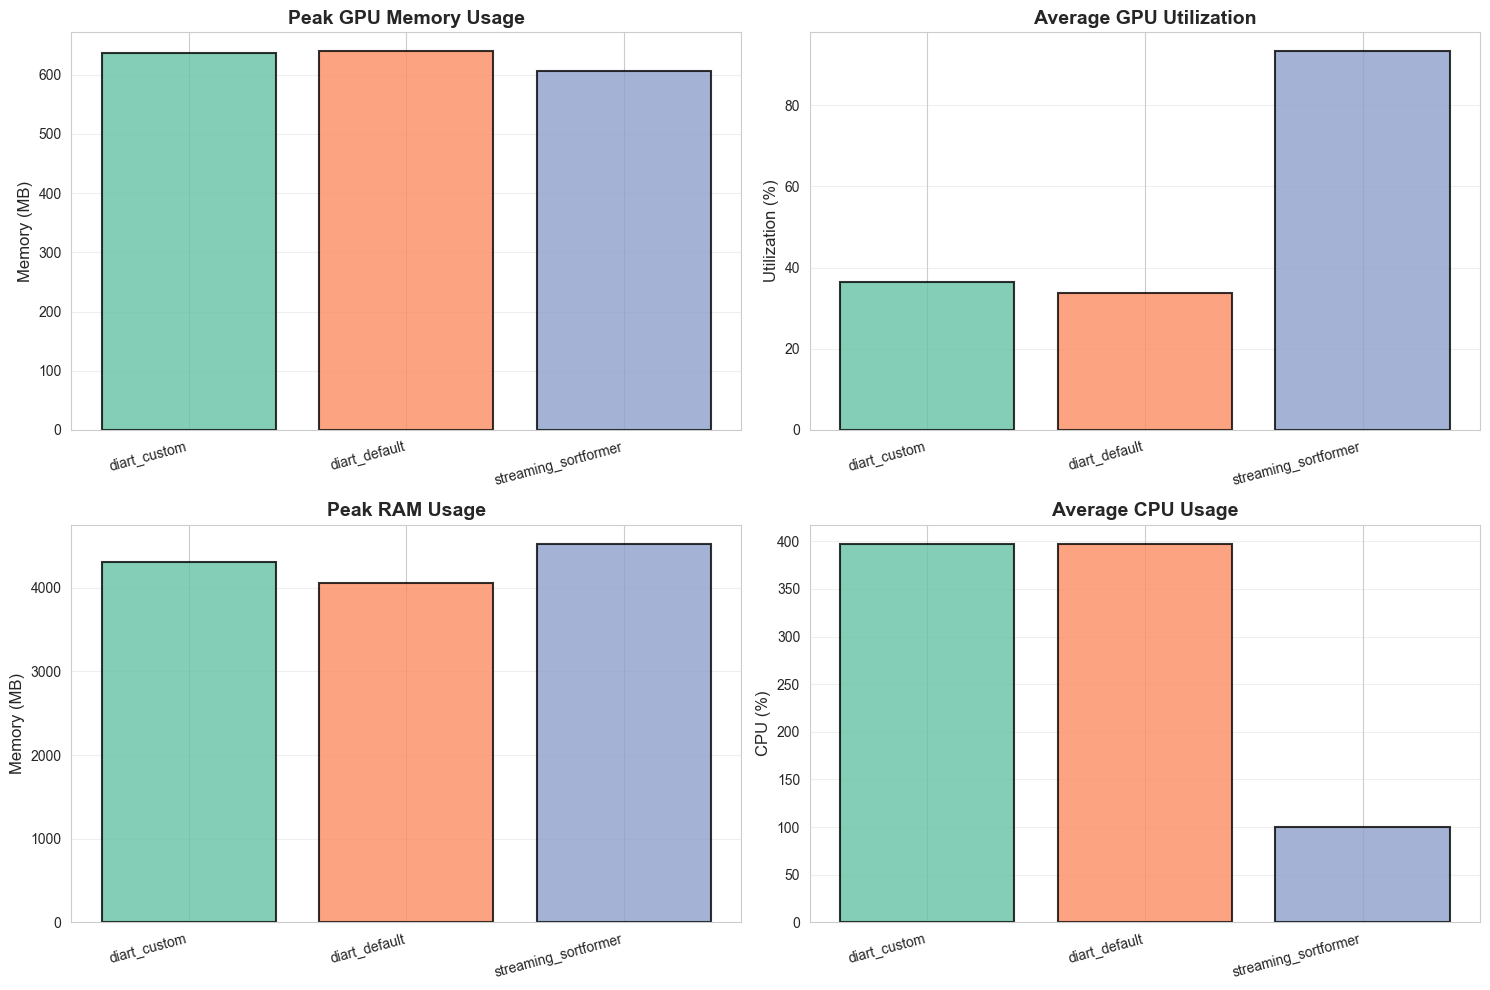

In [13]:
# Print resource usage statistics
stats_report.print_resource_statistics(df)

# Plot resource usage
visualizations.plot_resource_usage(df)

## Latency Analysis

Processing latency comparison across systems.


LATENCY STATISTICS (milliseconds)
                      latency_mean_ms  latency_std_ms  peak_latency_ms
system                                                                
diart_custom                  70.5805         25.8245         172.9149
diart_default                 68.5459         28.1884         185.4914
streaming_sortformer          50.8883          8.1991          72.0286


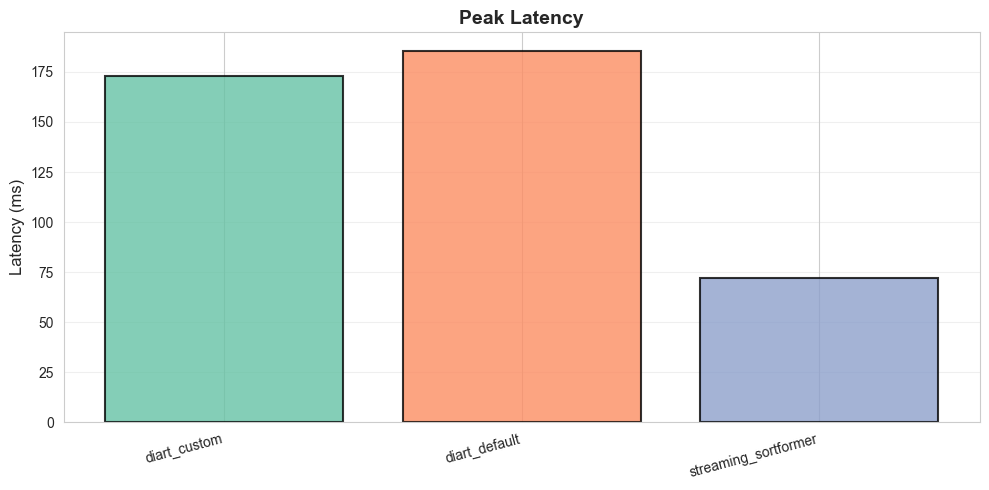

In [14]:
# Print latency statistics
stats_report.print_latency_statistics(df)

# Plot latency analysis
visualizations.plot_latency_analysis(df)